## Análisis de las variables downtime_gross, waiting_hours, parts_cost, 

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [74]:
df = pd.read_parquet('../Dataset limpiado/dataset unificado.parquet')
print(df.shape)

(140602, 33)


In [75]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,equipment,6661,int64,"[100268, 100312, 100884, 101632, 101638, 10172..."
1,operation,59,category,"[BIND LEG, BARTACK, SET SLEEVE, TOP STITCH HOO..."
2,wo_type,7,category,"[Corrective Maintenance, Breakdown, Preventati..."
3,base_model,119,category,"[VF2500, LT2-B872, W664, EX5214, VG2700, DLN54..."
4,problem_desc,24,category,"[It sews with defect / Cose con defecto, It do..."
5,failure_desc,38,category,[Machine head failure stopping sewing / Falla...
6,cause_desc,280,category,[Misadjusted machine head teeth / Dientes de c...
7,action_desc,278,category,[Adjust machine head teeth / Ajustar dientes d...
8,mechanic,185,category,"[Jaime Rivera, JERONIMO FUNEZ, Fabit Aranda, C..."
9,date,501,datetime64[ns],"[2023-10-03 00:00:00, 2024-01-17 00:00:00, 202..."


In [76]:
df_hist_downtime_gross_por_tipo_falla = df[['falla_grupo', 'downtime_gross']]

In [77]:
color_dict = {
    'Machine head failure stopping sewing  / Falla cabezal dejando de coser': "#1f53b4", 
    'Machine head failure sewing with defect / Falla cabezal cosiendo con defecto': "#c05619c8", 
    'Trim off device failure / Falla dispositivo corta desperdicio': "#2ca07d", 
    'Otros': "#27d6d6" 
}

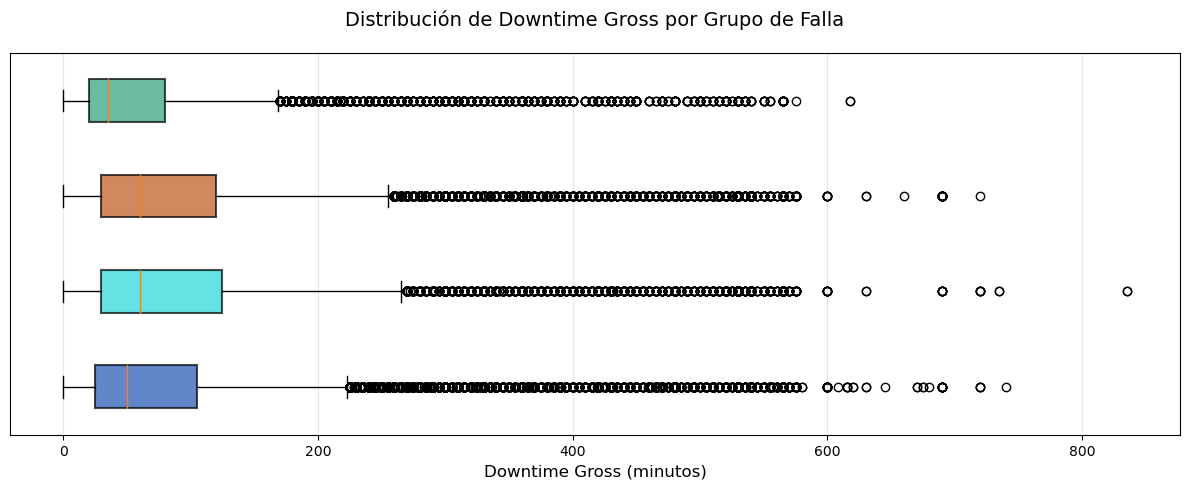

In [78]:
box_colors = [color_dict.get(grupo) for grupo in df_hist_downtime_gross_por_tipo_falla['falla_grupo']]

plt.figure(figsize=(12, 5))

# Boxplot con matplotlib para control total
fallas_unicas = df_hist_downtime_gross_por_tipo_falla['falla_grupo'].unique()
data = [df_hist_downtime_gross_por_tipo_falla[df_hist_downtime_gross_por_tipo_falla['falla_grupo'] == falla]['downtime_gross'].dropna() 
        for falla in fallas_unicas]

bp = plt.boxplot(data, 
                 labels=fallas_unicas,
                 vert=False,
                 patch_artist=True)

# Asignar colores según el diccionario
for box, falla in zip(bp['boxes'], fallas_unicas):
    box.set_facecolor(color_dict.get(falla))  # Color por defecto si no existe
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

plt.title('Distribución de Downtime Gross por Grupo de Falla', fontsize=14, pad=20)
plt.xlabel('Downtime Gross (minutos)', fontsize=12)
plt.ylabel('')
# plt.xticks([])
plt.yticks([])
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

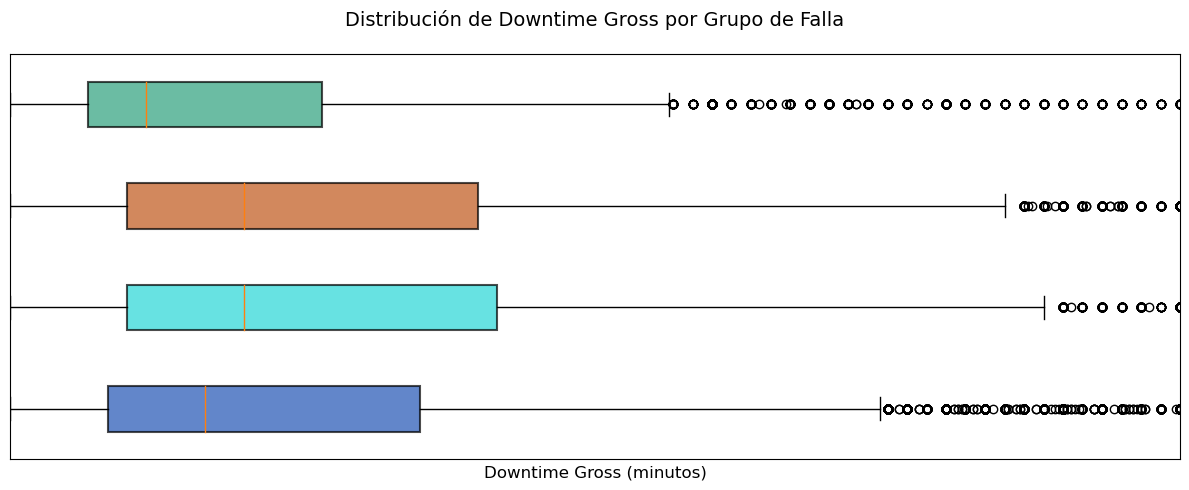

In [79]:
# Boxplot con matplotlib para control total
fallas_unicas = df_hist_downtime_gross_por_tipo_falla['falla_grupo'].unique()
data = [df_hist_downtime_gross_por_tipo_falla[df_hist_downtime_gross_por_tipo_falla['falla_grupo'] == falla]['downtime_gross'].dropna() 
        for falla in fallas_unicas]

plt.figure(figsize=(12, 5))
bp = plt.boxplot(data, 
                 labels=fallas_unicas,
                 vert=False,
                 patch_artist=True)

# Asignar colores según el diccionario
for box, falla in zip(bp['boxes'], fallas_unicas):
    box.set_facecolor(color_dict.get(falla))  # Color por defecto si no existe
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

plt.title('Distribución de Downtime Gross por Grupo de Falla', fontsize=14, pad=20)
plt.xlabel('Downtime Gross (minutos)', fontsize=12)
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.xlim(0, 300)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [80]:
df.columns

Index(['equipment', 'operation', 'wo_type', 'base_model', 'problem_desc',
       'failure_desc', 'cause_desc', 'action_desc', 'mechanic', 'date',
       'downtime_gross', 'pit_coverage', 'real_downtime', 'parts_cost',
       'repair_hours', 'waiting_hours', 'changed_pcs', 'days_between_failures',
       'age', 'antiquity', 'dia', 'semana', 'mes', 'problem_grupo',
       'falla_grupo', 'downtime_gross_h', 'pit_coverage_h', 'real_downtime_h',
       'repair_hours_h', 'waiting_hours_h', 'outlier', 'tiempo_outlier',
       'tiempo_normal'],
      dtype='object')

In [81]:
df_base_model = df[['base_model', 'waiting_hours', 'waiting_hours_h', 'repair_hours_h', 'repair_hours', 'age', 'parts_cost']].\
    groupby(['base_model']).agg(num_fallas=('base_model', 'count'),
                                waiting_hours_total=('waiting_hours_h', 'sum'),
                                repair_hours_total=('repair_hours_h', 'sum'),
                                parts_cost_total=('parts_cost', 'sum'),
                                age=('age', 'mean')
                                )

In [82]:
df_base_model = df_base_model.reset_index()
df_base_model

,base_model,num_fallas,waiting_hours_total,repair_hours_total,parts_cost_total,age
0,2211EY6701,721,1105.666667,946.050000,11242.98,21.162275
1,504-E256,82,5.916667,50.816667,944.35,16.463415
2,504-E51,44,0.166667,51.883333,232.20,13.136364
3,504-ETS51,31,0.333333,14.916667,82.86,22.032258
4,83SP,410,12.950000,337.116667,13796.56,20.573171
...,...,...,...,...,...,...
114,W600,1720,119.983333,1107.733333,15652.74,10.858140
115,W664,5002,687.300000,5173.450000,65936.75,21.089364
116,WT500,372,334.733333,424.816667,3134.42,24.185484
117,WT542,987,591.950000,1724.583333,7458.63,22.299899


In [83]:
# Identificamos los índices de los 5 modelos con más espera
top_5_indices = df_base_model.nlargest(5, 'waiting_hours_total').index

# Creamos una columna nueva que solo tenga el nombre para esos 5
df_base_model['etiqueta_top5'] = df_base_model.apply(
    lambda x: x['base_model'] if x.name in top_5_indices else '', axis=1 )

fig = px.scatter(
    df_base_model,
    x='age', 
    y='waiting_hours_total',
    size='num_fallas',
    text='etiqueta_top5',      # Solo mostrará texto para los 5 elegidos
    hover_name='base_model', # Muestra el nombre al pasar el ratón
    title='Análisis de Obsolescencia: Edad vs Espera',
    height=600, width=800,
)

# Ajustar para que el texto solo se vea en los puntos de arriba para no amontonar
fig.update_traces(textposition='top center')
fig.show()

In [87]:
# Identificamos los índices de los 5 modelos con más espera
top_5_indices = df_base_model.nlargest(5, 'parts_cost_total').index

# Creamos una columna nueva que solo tenga el nombre para esos 5
df_base_model['etiqueta_top5'] = df_base_model.apply(
    lambda x: x['base_model'] if x.name in top_5_indices else '', axis=1 )

fig = px.scatter(
    df_base_model,
    x='age', 
    y='parts_cost_total',
    size='num_fallas',
    text='etiqueta_top5',      # Solo mostrará texto para los 5 elegidos
    hover_name='base_model', # Muestra el nombre al pasar el ratón
    title='Análisis de Obsolescencia: Edad vs Coste de piezas',
    height=600, width=800,
)

# Ajustar para que el texto solo se vea en los puntos de arriba para no amontonar
fig.update_traces(textposition='top center')
fig.show()